In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from astropy.stats import bayesian_blocks

from Kakapo.photometry import forced_photometry
from Kakapo.cleaning_curve import gauss_smooth

%matplotlib widget

In [2]:
diff_file = '/Users/zgl12/Modules/Kakapo/Data/difference_arrays/c3/diff_c3_t205922648.npy'

diff = np.load(diff_file)

In [ ]:
# lc_time = np.load('/Users/zgl12/Modules/Kakapo/lc_time.npy')
# lc_flux = np.load('/Users/zgl12/Modules/Kakapo/lc_flux.npy')
# lc_flux_err = np.load('/Users/zgl12/Modules/Kakapo/lc_flux_err.npy')

# mask = np.isfinite(lc_flux) & np.isfinite(lc_time) & np.isfinite(lc_flux_err)

# masked_lc_time = lc_time[mask]
# masked_lc_flux = lc_flux[mask]
# masked_lc_flux_err = lc_flux_err[mask]

In [3]:
lc_flux = forced_photometry(diff, 6.36, 6.35, None)
lc_time = np.load('/Users/zgl12/Modules/Kakapo/lc_time.npy')

mask = np.isfinite(lc_flux) & np.isfinite(lc_time) #& np.isfinite(lc_flux_err)

masked_lc_time = lc_time[mask]
masked_lc_flux = lc_flux[mask]
# masked_lc_flux_err = lc_flux_err[mask]

smoothed_lc, smooth_err = gauss_smooth(masked_lc_time, masked_lc_flux, None)

# smoothed_lc_new, smoothed_lc_new_err, scale = gauss_smooth_weighted(masked_lc_time, masked_lc_flux, masked_lc_flux_err)

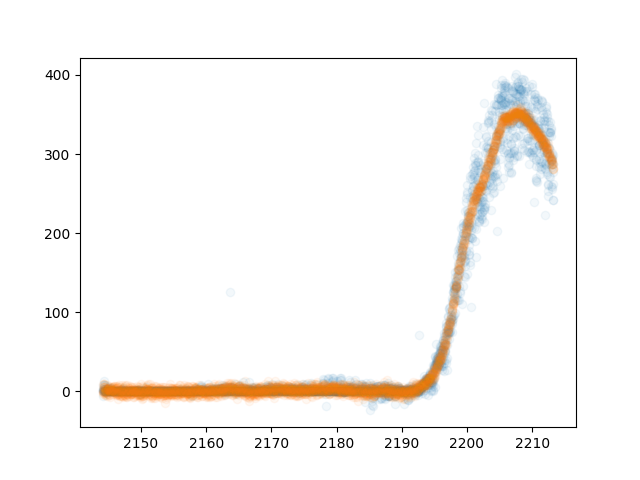

In [6]:
plt.figure()
# plt.errorbar(lc_time, lc_flux, lc_flux_err, fmt = '.', alpha = 0.05)
# plt.errorbar(masked_lc_time, masked_lc_flux, masked_lc_flux_err, fmt = '.', alpha = 0.05)
# plt.errorbar(masked_lc_time, smoothed_lc, smooth_err, fmt = '.', alpha = 0.05)
# plt.errorbar(masked_lc_time, smoothed_mean, smooth_err, fmt = '.', alpha = 0.05)
plt.scatter(masked_lc_time, masked_lc_flux, alpha = 0.05)
plt.scatter(masked_lc_time, smoothed_lc, alpha = 0.05)
# plt.scatter(masked_lc_time, smoothed_mean, alpha = 0.05)
plt.show()

In [ ]:
smooth_err

In [ ]:
file = '/Users/zgl12/Modules/Kakapo/Data/detected_events/c3/events_c3_t205922648.csv'

df = pd.read_csv(file)

In [ ]:
df

In [ ]:
54832.5 + df.time_min.values[0]

In [ ]:
lc_sig = np.load('/Users/zgl12/Modules/Kakapo/lc_significance.npy')

lc_sig.shape # np.column_stack([bjds, lc_sm, lc_sig])

In [ ]:
plt.figure()
plt.scatter(lc_sig[:,0], lc_sig[:,1])
plt.show()

plt.figure()
plt.scatter(lc_sig[:,0], lc_sig[:,3])
plt.ylabel('Significance')
plt.xlabel('Time')
plt.show()

In [ ]:
# edges = bayesian_blocks(lc_sig[:,0], lc_sig[:,1], fitness='measures',
#                         sigma=lc_sig[:,2]*10, p0=0.1)

In [ ]:
# block_idx, block_means = [], []
# for i in range(len(edges)-1):
#     mask = (lc_sig[:,0] >= edges[i]) & (lc_sig[:,0] < edges[i+1] if i < len(edges)-2 else lc_sig[:,0] <= edges[i+1])
#     if not np.any(mask): 
#         continue
#     block_idx.append(np.where(mask)[0])
#     block_means.append(np.nanmean(lc_sig[:,1][mask]))

# baseline_val = np.nanmedian(block_means[:2])
# above = [m - baseline_val > 2*np.nanstd(lc_sig[:,2]) for m in block_means]

# # Pick first run overlapping cluster
# istart, iend = None, None
# for idx, ok in zip(block_idx, above):
#     if ok and (idx[0] <= 3378 and idx[-1] >= 2695):
#         istart, iend = idx[0], idx[-1]
#         print(istart, iend)
 

In [ ]:
# plt.figure()
# plt.scatter(lc_sig[:,0], lc_sig[:,1])
# plt.axvline(lc_sig[:,0][iend], color = 'r')
# plt.axvline(lc_sig[:,0][istart], color = 'r')
# plt.show()